In [2]:
!pip install transformers datasets scikit-learn torch pandas

In [3]:
import json
import copy
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,roc_curve, auc, roc_auc_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#split_Data

INPUT_PATH = "/content/drive/MyDrive/DSCI_510/dailydialog/train.jsonl"
#INPUT_PATH = "/content/drive/MyDrive/DSCI_510/empathetic/train.jsonl"
#INPUT_PATH = "/content/drive/MyDrive/DSCI_510/go_emotions/train.jsonl"
#INPUT_PATH = "/content/drive/MyDrive/DSCI_510/mixed_data/train.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/DSCI_510/splits"

LABELS = ["negative", "neutral", "positive"]

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)



# read the data from the processed data
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            text = str(obj.get("input", "")).strip().replace("_comma_", ",")
            label = str(obj.get("output", "")).strip().lower()
            if not text or label not in LABELS:
                continue
            rows.append({"input": text, "output": label})
    return rows


#save the data into json file
def save_jsonl(rows, path):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

data = load_jsonl(INPUT_PATH)

texts = [x["input"] for x in data]
labels = [x["output"] for x in data]




# Split the train data into validation & test data
x_train, x_temp, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


# Split the rest data into validation & test data
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

train_rows = [{"input": x, "output": y} for x, y in zip(x_train, y_train)]
val_rows = [{"input": x, "output": y} for x, y in zip(x_val, y_val)]
test_rows = [{"input": x, "output": y} for x, y in zip(x_test, y_test)]

save_jsonl(train_rows, f"{OUTPUT_DIR}/train.jsonl")
save_jsonl(val_rows, f"{OUTPUT_DIR}/val.jsonl")
save_jsonl(test_rows, f"{OUTPUT_DIR}/test.jsonl")

print("The data description")
print("train:", len(train_rows))
print("val:", len(val_rows))
print("test:", len(test_rows))

The data description
train: 8000
val: 1000
test: 1000


In [ ]:
# Variable config
DATA_DIR = "/content/drive/MyDrive/DSCI_510/splits"
TRAIN_PATH = f"{DATA_DIR}/train.jsonl"
VAL_PATH = f"{DATA_DIR}/val.jsonl"
TEST_PATH = f"{DATA_DIR}/test.jsonl"
OUTPUT_DIR = "/content/final_models"
MODEL_NAME ="roberta-base"
LABELS = ["negative", "neutral", "positive"]
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

SEEDS = [42, 43, 44]   # determine how many seeds should be create in the ensemble cluster
MAX_LENGTH = 160
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# AI generated: provided the best torch cuda setting
# ++++++++++++++++++++++++++++++
if torch.cuda.is_available():
    TRAIN_BATCH_SIZE = 16
    EVAL_BATCH_SIZE = 32
else:
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 8
# ++++++++++++++++++++++++++++++

# =========================
# Utils
# =========================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def load_jsonl_for_model(path: str):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            text = str(obj.get("input", "")).strip().replace("_comma_", ",")
            label = str(obj.get("output", "")).strip().lower()
            if not text or label not in label2id:
                continue
            rows.append({"text": text, "label": label2id[label]})
    return rows

class EncodedDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

def build_dataset(rows, tokenizer):
    texts = [r["text"] for r in rows]
    labels = torch.tensor([r["label"] for r in rows], dtype=torch.long)

    encodings = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    return EncodedDataset(encodings, labels)

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_count = 0


# AI generated: provided the torch cuda setting
# ++++++++++++++++++++++++++++++
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=-1)

            bs = batch["labels"].size(0)
            total_loss += loss.item() * bs
            total_count += bs

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(batch["labels"].cpu().numpy().tolist())

# ++++++++++++++++++++++++++++++
    avg_loss = total_loss / max(total_count, 1)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1_macro": f1,
        "confusion_matrix": cm,
    }



# AI polished code: focus on torch setup
# ++++++++++++++++++++++++++++++
def train_one_seed(seed, train_rows, val_rows, test_rows):
    set_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n===== Seed {seed} | device = {device} =====")

    # get the pretrained model to run better
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    train_ds = build_dataset(train_rows, tokenizer)
    val_ds = build_dataset(val_rows, tokenizer)
    test_ds = build_dataset(test_rows, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_val_f1 = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for step, batch in enumerate(train_loader, start=1):
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()

            if use_amp:
                with torch.cuda.amp.autocast():
                    outputs = model(**batch)
                    loss = outputs.loss
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(**batch)
                loss = outputs.loss
                loss.backward()
                optimizer.step()

            bs = batch["labels"].size(0)
            running_loss += loss.item() * bs
            seen += bs

        train_loss = running_loss / max(seen, 1)
        val_metrics = evaluate(model, val_loader, device)
# ++++++++++++++++++++++++++++++

        print(
            f"Epoch {epoch}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    test_metrics = evaluate(model, test_loader, device)

    # save only one final model per seed
    seed_dir = Path(OUTPUT_DIR) / f"seed_{seed}" / "best_model"
    seed_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(str(seed_dir))
    tokenizer.save_pretrained(str(seed_dir))

    print(f"\nBest epoch for seed {seed}: {best_epoch}")
    print(f"Saved to: {seed_dir}")
    print(f"Test acc: {test_metrics['accuracy']:.4f}")
    print(f"Test f1 : {test_metrics['f1_macro']:.4f}")
    print("Confusion matrix:")
    print(test_metrics["confusion_matrix"])

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "val_f1": best_val_f1,
        "test_acc": test_metrics["accuracy"],
        "test_f1": test_metrics["f1_macro"],
        "model_dir": str(seed_dir),
    }

def main():
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))
    print("model:", MODEL_NAME)

    train_rows = load_jsonl_for_model(TRAIN_PATH)
    val_rows = load_jsonl_for_model(VAL_PATH)
    test_rows = load_jsonl_for_model(TEST_PATH)

    if not train_rows or not val_rows or not test_rows:
        raise ValueError("one of the file did not have the ")

    print("train:", len(train_rows))
    print("val:", len(val_rows))
    print("test:", len(test_rows))

    results = []
    for seed in SEEDS:
        results.append(train_one_seed(seed, train_rows, val_rows, test_rows))

    print("\n===== Summary =====")
    for r in results:
        print(
            f"seed={r['seed']} | best_epoch={r['best_epoch']} | "
            f"val_f1={r['val_f1']:.4f} | test_f1={r['test_f1']:.4f} | test_acc={r['test_acc']:.4f}"
        )

if __name__ == "__main__":
    main()

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
model: roberta-base
train: 8000
val: 1000
test: 1000

===== Seed 42 | device = cuda =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

/tmp/ipykernel_8392/95188399.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/5 | train_loss=0.6425 | val_loss=0.6493 | val_acc=0.7440 | val_f1=0.7426


/tmp/ipykernel_8392/95188399.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 3/5 | train_loss=0.5482 | val_loss=0.6879 | val_acc=0.7340 | val_f1=0.7320


/tmp/ipykernel_8392/95188399.py:166: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [6]:
#等權重平均三個模型
!cp -r /content/final_models/ /content/drive/MyDrive/DSCI_510/mixed_data/final_models/


device: cpu
loading: /content/drive/MyDrive/DSCI_Roberta_base_ensembler/empathetic/final_models/seed_42/best_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

loading: /content/drive/MyDrive/DSCI_Roberta_base_ensembler/empathetic/final_models/seed_43/best_model


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

loading: /content/drive/MyDrive/DSCI_Roberta_base_ensembler/empathetic/final_models/seed_44/best_model


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


Running validation inference...
  model 1/3
  model 2/3
  model 3/3

===== Equal-weight val result =====
val_acc = 0.7060
val_f1  = 0.7043

Val confusion matrix:
[[268  29  37]
 [ 42 230  61]
 [ 75  50 208]]

Plotting validation ROC AUC...
macro-average AUC = 0.8664
ROC figure saved to: /content/roc_auc_val.png


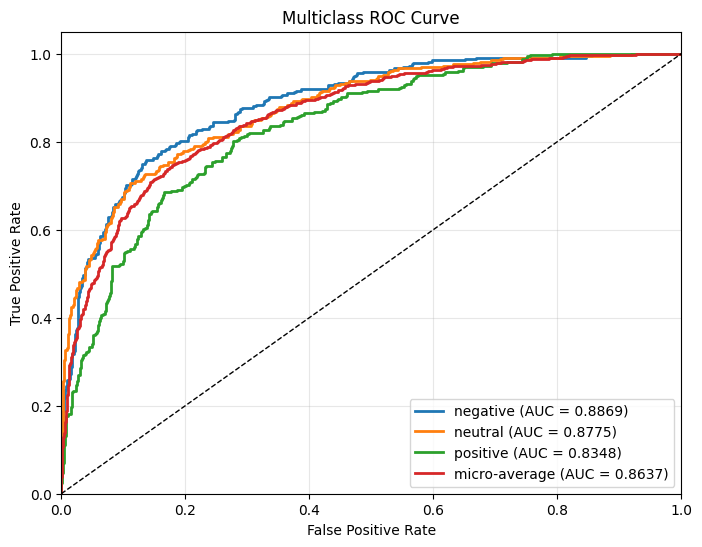

Precision/Recall figure saved to: /content/precision_recall_val.png


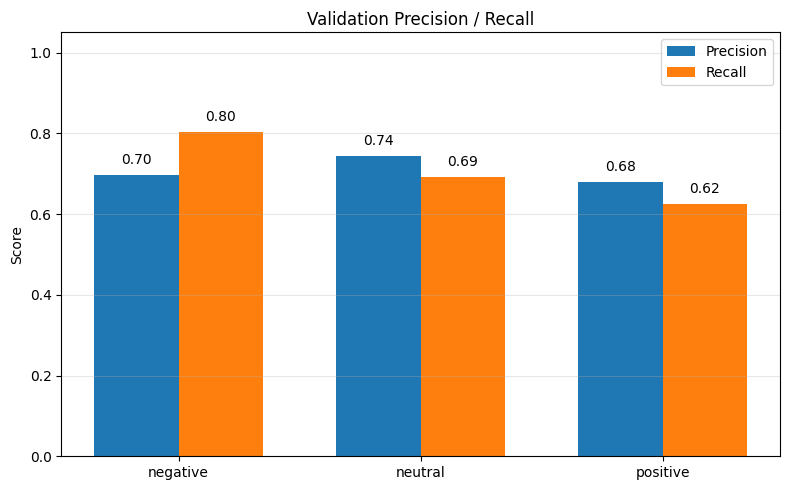

Per-class precision: {'negative': np.float64(0.6961), 'neutral': np.float64(0.7443), 'positive': np.float64(0.6797)}
Per-class recall   : {'negative': np.float64(0.8024), 'neutral': np.float64(0.6907), 'positive': np.float64(0.6246)}
Support            : {'negative': np.int64(334), 'neutral': np.int64(333), 'positive': np.int64(333)}
Saved to /content/val_metrics.png


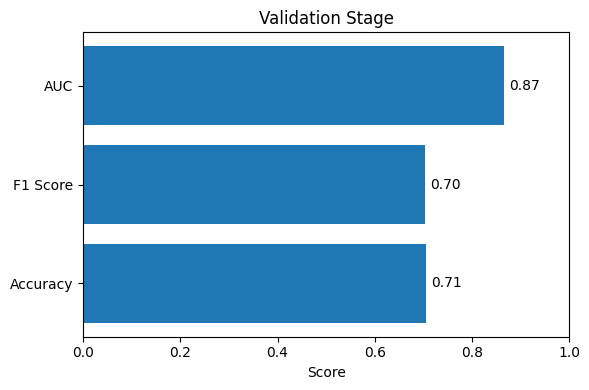


Running test inference...
  model 1/3
  model 2/3
  model 3/3

===== Equal-weight test result =====
test_acc = 0.6470
test_f1  = 0.6455

Confusion matrix:
[[247  42  45]
 [ 61 198  74]
 [ 78  53 202]]

Plotting test ROC AUC...
macro-average AUC = 0.8292
ROC figure saved to: /content/roc_auc_test.png


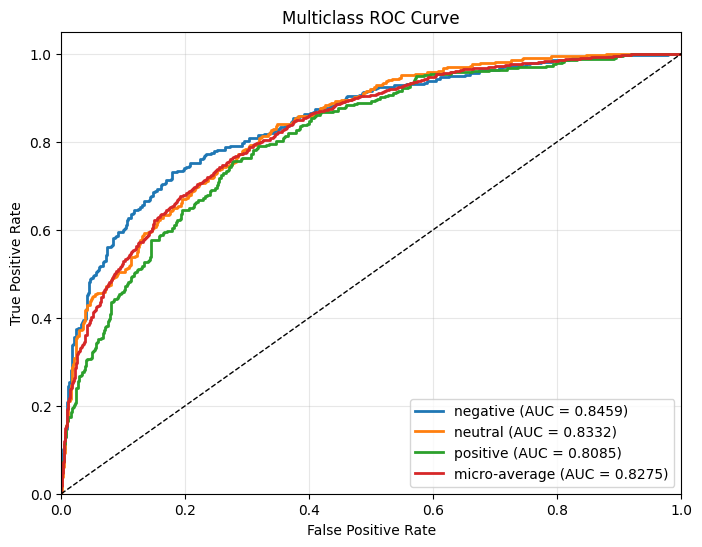

Precision/Recall figure saved to: /content/precision_recall_test.png


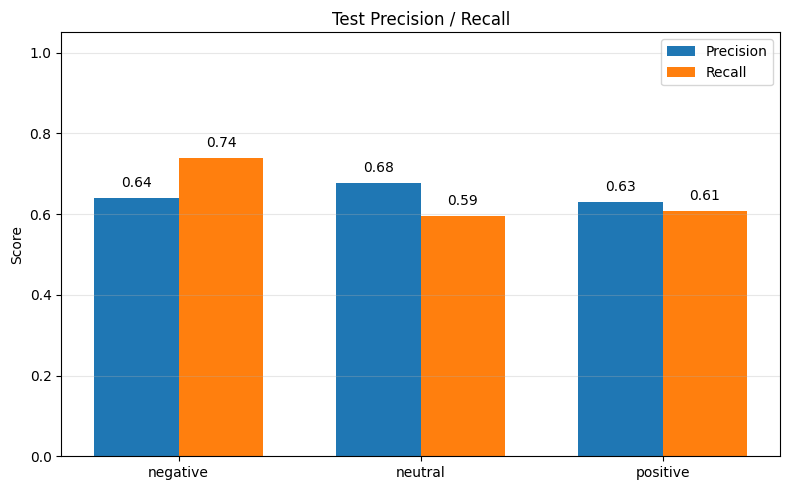

Per-class precision: {'negative': np.float64(0.6399), 'neutral': np.float64(0.6758), 'positive': np.float64(0.6293)}
Per-class recall   : {'negative': np.float64(0.7395), 'neutral': np.float64(0.5946), 'positive': np.float64(0.6066)}
Support            : {'negative': np.int64(334), 'neutral': np.int64(333), 'positive': np.int64(333)}
{'accuracy': 0.647, 'f1_macro': 0.6454786578647117, 'confusion_matrix': array([[247,  42,  45],
       [ 61, 198,  74],
       [ 78,  53, 202]]), 'auc': np.float64(0.8292210011589843)}
Saved to /content/test_metrics.png


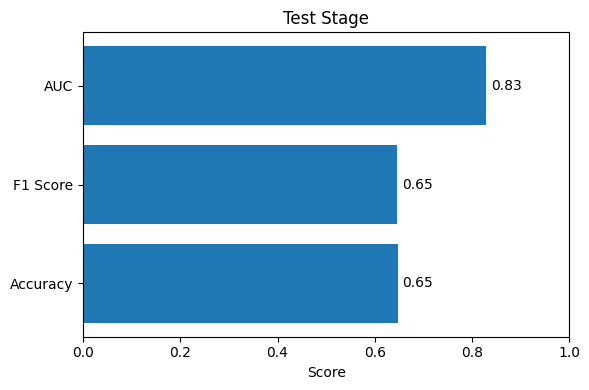


Sample predictions:
My brother recently proposed to his girlfriend, I'm really happy for him. :) => positive
What was going on with her? => negative
How thoughtful. Now you have to pay it forward, as the saying goes. => positive
Recently, I received the news about my ex boyfriend's relapse. => negative
Oniony gold! That's a very apt description! => positive
I usually do pretty good on short flights. Longer ones make me a little nervous. => negative
I know I'm not a perfect parent but some just aren't good at it or don't care. => negative
She's a female singer. It sort of burns me up because I feel like she doesn't deserve it and she's rather manipulative. => negative
It always seems to work out like that doesn't it? => neutral
Yeah! It gave me all of the feels. I read through them and pretty much fell in love with her all over again. => neutral


In [7]:
# MODEL_DIRS = [
#     "/content/final_models/seed_42/best_model",
#     "/content/final_models/seed_43/best_model",
#     "/content/final_models/seed_44/best_model",
# ]


target = "empathetic"


MODEL_DIRS = [
    f"/content/drive/MyDrive/DSCI_Roberta_base_ensembler/{target}/final_models/seed_42/best_model",
    f"/content/drive/MyDrive/DSCI_Roberta_base_ensembler/{target}/final_models/seed_43/best_model",
    f"/content/drive/MyDrive/DSCI_Roberta_base_ensembler/{target}/final_models/seed_44/best_model",
]

VAL_PATH = f"/content/drive/MyDrive/DSCI_Roberta_base_ensembler/{target}/validation.jsonl"
TEST_PATH =f"/content/drive/MyDrive/DSCI_Roberta_base_ensembler/{target}/test.jsonl"

MAX_LENGTH = 128
BATCH_SIZE = 16

LABELS = ["negative", "neutral", "positive"]
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            text = str(obj.get("input", "")).strip().replace("_comma_", ",")
            label = str(obj.get("output", "")).strip().lower()
            row = {"text": text}
            if label in label2id:
                row["labels"] = label2id[label]
            rows.append(row)
    return rows

def predict_probs(model, tokenizer, texts):
    device = next(model.parameters()).device
    model.eval()
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i + BATCH_SIZE]
            enc = tokenizer(
                batch,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy())

    return np.concatenate(all_probs, axis=0)

def evaluate_probs(probs, labels):
    preds = np.argmax(probs, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "confusion_matrix": confusion_matrix(labels, preds, labels=[0, 1, 2]),
    }

def plot_multiclass_roc(y_true, y_prob, class_names, save_path=None):
    """
    y_true: shape (N,)
    y_prob: shape (N, C)
    """
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(8, 6))

    roc_auc_dict = {}
    valid_class_count = 0

    for i, name in enumerate(class_names):
        # skip if a class does not appear in y_true
        if len(np.unique(y_true_bin[:, i])) < 2:
            print(f"Skipping ROC for class '{name}' because only one class is present in y_true.")
            continue

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        roc_auc_dict[name] = roc_auc
        valid_class_count += 1

        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

    # micro-average ROC
    if valid_class_count > 0:
        fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        plt.plot(
            fpr_micro,
            tpr_micro,
            linewidth=2,
            label=f"micro-average (AUC = {auc_micro:.4f})",
        )

        try:
            auc_macro = roc_auc_score(
                y_true_bin,
                y_prob,
                average="macro",
                multi_class="ovr",
            )
            print(f"macro-average AUC = {auc_macro:.4f}")
        except Exception as e:
            print("macro-average AUC could not be computed:", e)

    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")


    plt.title("Multiclass ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"ROC figure saved to: {save_path}")

    plt.show()

    return auc_macro

def plot_precision_recall_bars(y_true, y_pred, class_names, title, save_path=None):
    precision, recall, _, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        zero_division=0
    )

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(8, 5))

    bars1 = plt.bar(x - width/2, precision, width, label="Precision")
    bars2 = plt.bar(x + width/2, recall, width, label="Recall")

    plt.xticks(x, class_names)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    for bars in [bars1, bars2]:
      for bar in bars:
          height = bar.get_height()
          plt.text(
              bar.get_x() + bar.get_width() / 2,
              height + 0.02,
              f"{height:.2f}",
              ha='center',
              va='bottom',
              fontsize=10
          )

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Precision/Recall figure saved to: {save_path}")

    plt.show()

    print("Per-class precision:", dict(zip(class_names, np.round(precision, 4))))
    print("Per-class recall   :", dict(zip(class_names, np.round(recall, 4))))
    print("Support            :", dict(zip(class_names, support)))


def plot_f1_acc_auc_metrics(metrics_dict, title, save_path=None):


    acc = metrics_dict["accuracy"]
    f1  = metrics_dict["f1_macro"]
    auc = metrics_dict["auc"]

    plt.figure(figsize=(6, 4))

    labels = ["Accuracy", "F1 Score", "AUC"]
    values = [acc, f1, auc]

    bars = plt.barh(labels, values)

    plt.xlim(0, 1)
    plt.xlabel("Score")
    plt.title(title)

    for bar, v in zip(bars, values):
        plt.text(
            v + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{v:.2f}",
            va="center"
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()

def main():
    val_data = load_jsonl(VAL_PATH)
    test_data = load_jsonl(TEST_PATH)

    val_texts = [x["text"] for x in val_data if "labels" in x]
    test_texts = [x["text"] for x in test_data if "labels" in x]
    val_labels = np.array([x["labels"] for x in val_data if "labels" in x], dtype=np.int64)
    test_labels = np.array([x["labels"] for x in test_data if "labels" in x], dtype=np.int64)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIRS[0], local_files_only=True)

    models = []
    for d in MODEL_DIRS:
        print("loading:", d)
        model = AutoModelForSequenceClassification.from_pretrained(
            d,
            local_files_only=True
        )
        model.to(device)
        models.append(model)

    print("\nRunning validation inference...")
    val_probs_sum = None
    for i, model in enumerate(models, 1):
        print(f"  model {i}/{len(models)}")
        probs = predict_probs(model, tokenizer, val_texts)
        val_probs_sum = probs if val_probs_sum is None else (val_probs_sum + probs)

    val_mix = val_probs_sum / len(models)
    val_metrics = evaluate_probs(val_mix, val_labels)

    print("\n===== Equal-weight val result =====")
    print(f"val_acc = {val_metrics['accuracy']:.4f}")
    print(f"val_f1  = {val_metrics['f1_macro']:.4f}")
    print("\nVal confusion matrix:")
    print(val_metrics["confusion_matrix"])

    print("\nPlotting validation ROC AUC...")
    auc_val = plot_multiclass_roc(
        val_labels,
        val_mix,
        LABELS,
        save_path="/content/roc_auc_val.png"
    )

    val_preds = np.argmax(val_mix, axis=-1)
    plot_precision_recall_bars(
        val_labels,
        val_preds,
        LABELS,
        title="Validation Precision / Recall",
        save_path="/content/precision_recall_val.png"
    )


    val_metrics["auc"] = auc_val
    plot_f1_acc_auc_metrics(
        val_metrics,
        title="Validation Stage",
        save_path="/content/val_metrics.png"
    )

    print("\nRunning test inference...")
    test_probs_sum = None
    for i, model in enumerate(models, 1):
        print(f"  model {i}/{len(models)}")
        probs = predict_probs(model, tokenizer, test_texts)
        test_probs_sum = probs if test_probs_sum is None else (test_probs_sum + probs)

    test_mix = test_probs_sum / len(models)
    test_metrics = evaluate_probs(test_mix, test_labels)

    print("\n===== Equal-weight test result =====")
    print(f"test_acc = {test_metrics['accuracy']:.4f}")
    print(f"test_f1  = {test_metrics['f1_macro']:.4f}")
    print("\nConfusion matrix:")
    print(test_metrics["confusion_matrix"])

    print("\nPlotting test ROC AUC...")
    auc_test = plot_multiclass_roc(
        test_labels,
        test_mix,
        LABELS,
        save_path="/content/roc_auc_test.png"
    )


    test_preds = np.argmax(test_mix, axis=-1)
    plot_precision_recall_bars(
        test_labels,
        test_preds,
        LABELS,
        title="Test Precision / Recall",
        save_path="/content/precision_recall_test.png"
    )



    test_metrics["auc"] = auc_test

    print(test_metrics)

    plot_f1_acc_auc_metrics(
        test_metrics,
        title="Test Stage",
        save_path="/content/test_metrics.png"
    )

    preds = np.argmax(test_mix, axis=-1)
    print("\nSample predictions:")
    for i in range(min(10, len(test_texts))):
        print(test_texts[i], "=>", id2label[int(preds[i])])

if __name__ == "__main__":
    main()